For my portion of the analysis, I looked at incorporating FEMA disaster declarations to our master dataset. In the first cell, the FEMA data is loaded and cleaned as necessary. I also engineered a few new features on the dataset that will be used in the models trained, being layoffs per capita, workers affected per capita, lagged variables, and real zhvi (using historical CPI) to account for inflation. Once done, EDA  is performed which revealed that real ZHVI was heavily right skewed, resulting in the need to log transform the data.To visually look at relationships and check for a linear trend, log zhvi real was also plotted against per capita layoff impact. 

To understand the relationships within the data, a baseline linear regression model was built first, with cross validation. Stepwise selection was performed to identify the most significant variables wthin the model, and the model was validated further using residual plots. As the given dataset was state level, a mixed-effect model with state as the random effect was developed, allowing for a more nuanced look at how factors impact home values accross states. Performance of all models were evaluated on the test set, and can be compared to one another.

Required R Packages:
-dplyr
-lubridate
-ggplot2
-gridExtra
-boot
-Metrics
-lme4

In [1]:
library(dplyr)
library(ggplot2)
library(gridExtra)
library(boot)
library(Metrics)
library(lme4)
theme_update(text = element_text(family = "Times New Roman"))
par(family = "Times New Roman")


final_data <- read.csv("master_with_disasters.csv")
head(final_data)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'gridExtra' was built under R version 4.4.3"

Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


Warning message:
"package 'Metrics' was built under R version 4.4.3"
Loading required package: Matrix



,state,year,zhvi_avg,warn_events,workers_affected,closures,layoffs,pop,births,deaths,netmig,disaster_declarations,workers_affected_per_capita,layoffs_per_capita,layoffs_per_capita_lag1,layoffs_per_capita_lag2,disaster_declarations_lag1,cpi,zhvi_real
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,Alabama,2010,125684.4,30,3993,21,9,4785514,NA,NA,NA,3,0.0008343931,1.880676e-06,NA,NA,NA,218.056,125684.4
2,Alabama,2011,119875.3,36,5445,22,14,4799642,NA,NA,NA,134,0.0011344596,2.916884e-06,1.880676e-06,NA,3,224.939,116207.2
3,Alabama,2012,121659.0,32,5156,18,14,4816632,NA,NA,NA,11,0.0010704575,2.906595e-06,2.916884e-06,1.880676e-06,134,229.594,115545.1
4,Alabama,2013,128972.4,41,7329,26,15,4831586,NA,NA,NA,0,0.0015168932,3.104571e-06,2.906595e-06,2.916884e-06,11,232.957,120722.8
5,Alabama,2014,133206.1,17,4454,9,8,4843737,NA,NA,NA,21,0.0009195380,1.651617e-06,3.104571e-06,2.906595e-06,0,236.736,122695.3
6,Alabama,2015,135095.1,26,4946,13,13,4854803,NA,NA,NA,0,0.0010187849,2.677761e-06,1.651617e-06,3.104571e-06,21,237.017,124287.7


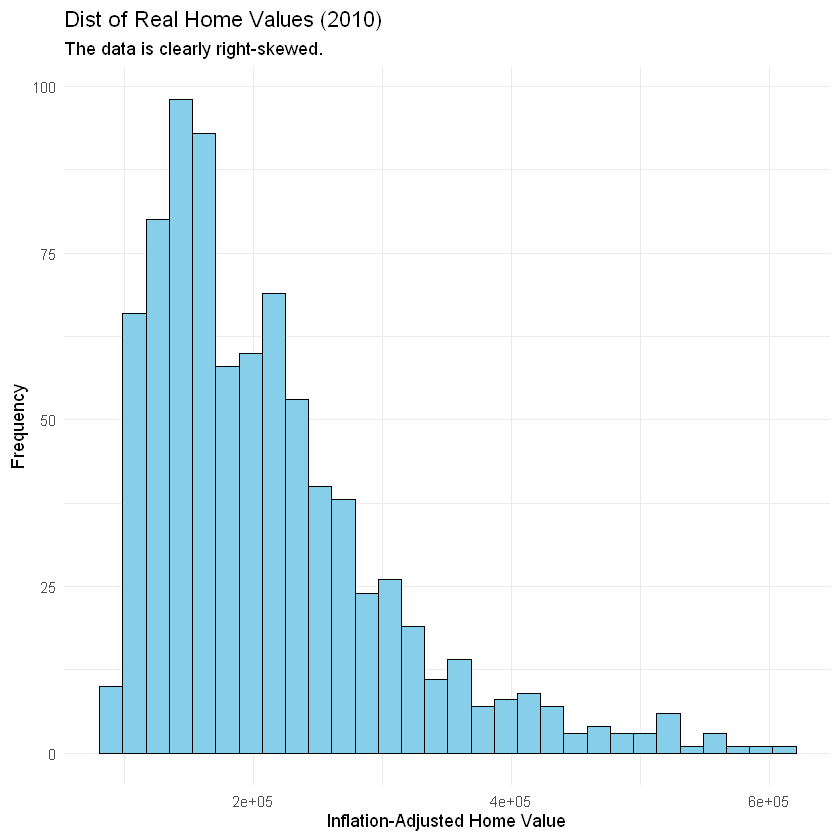

In [2]:
normal_plot <- ggplot(final_data, aes(x = zhvi_real)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "black") +
  labs(title = "Dist of Real Home Values (2010)",
       subtitle = "The data is clearly right-skewed.",
       x = "Inflation-Adjusted Home Value",
       y = "Frequency") +
  theme_minimal()
  print(normal_plot)

Realized the data was skewed  from the above visual so log transformed it

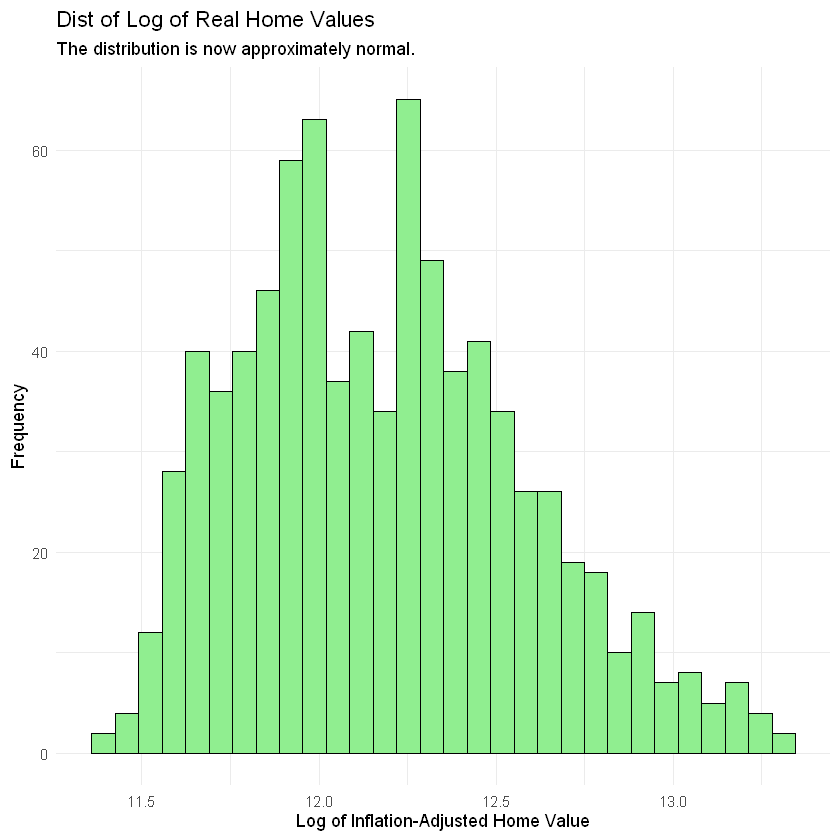

In [3]:
final_data <- final_data %>%
  mutate(log_zhvi_real = log(zhvi_real))
log_trans_plot <- ggplot(final_data, aes(x = log_zhvi_real)) +
  geom_histogram(bins = 30, fill = "lightgreen", color = "black") +
  labs(title = "Dist of Log of Real Home Values",
       subtitle = "The distribution is now approximately normal.",
       x = "Log of Inflation-Adjusted Home Value",
       y = "Frequency") +
  theme_minimal()
  print(log_trans_plot)

Thought the below two charts might be a cool show in the report, as it may be applicable for the wider group

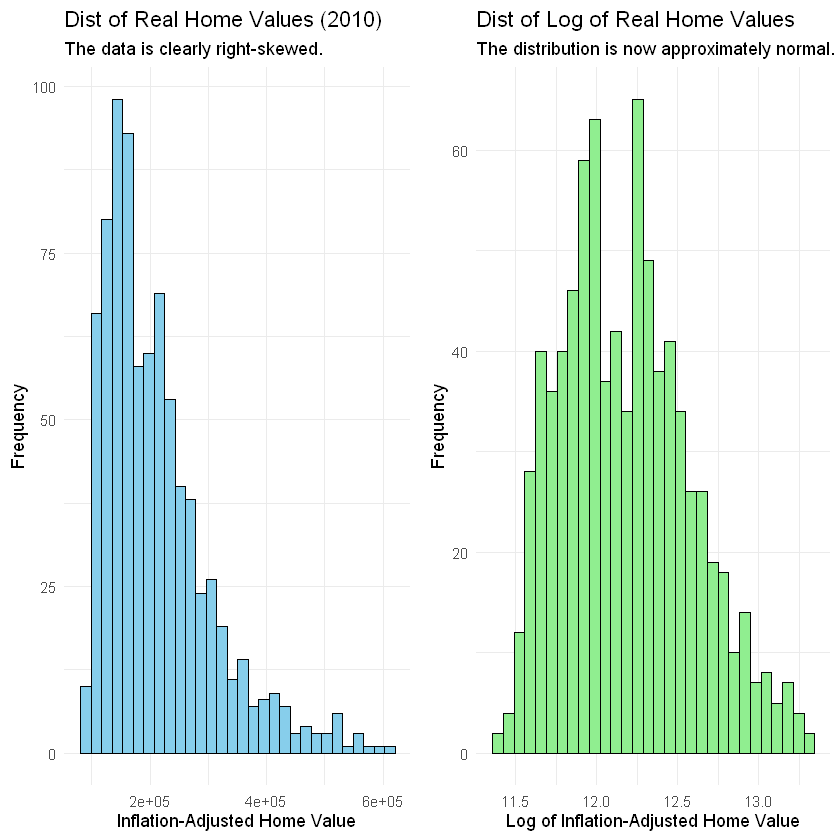

In [4]:
grid.arrange(normal_plot, log_trans_plot, ncol = 2)


`geom_smooth()` using formula = 'y ~ x'


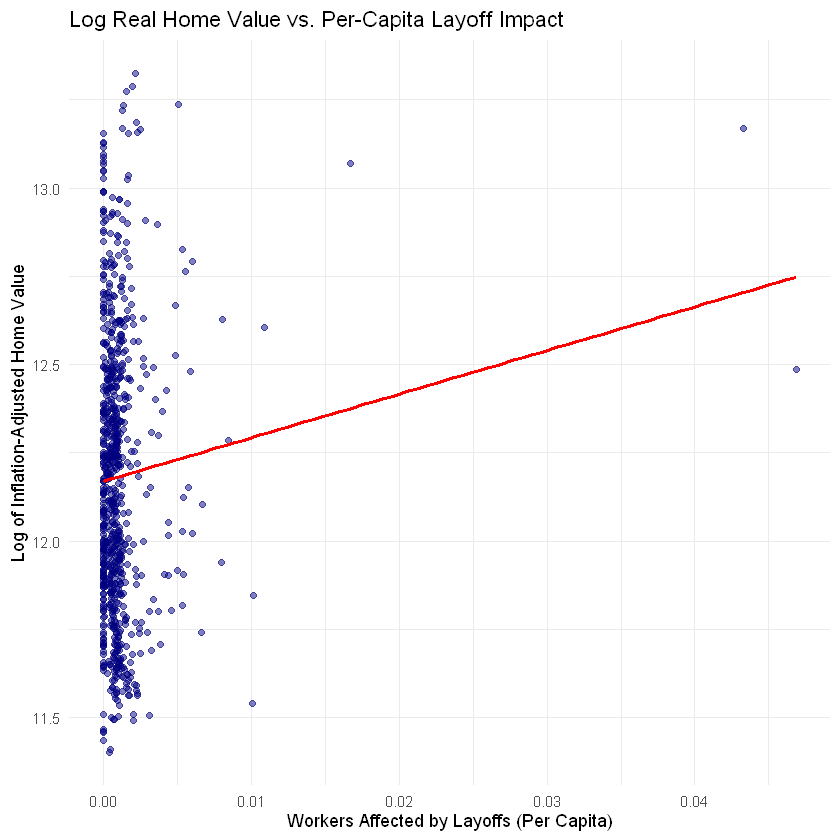

In [5]:
ggplot(final_data, aes(x = workers_affected_per_capita, y = log_zhvi_real)) +
  geom_point(alpha = 0.5, color = "navy") +
  geom_smooth(method = "lm", col = "red", se = FALSE) +
  labs(title = "Log Real Home Value vs. Per-Capita Layoff Impact",
       x = "Workers Affected by Layoffs (Per Capita)",
       y = "Log of Inflation-Adjusted Home Value") +
  theme_minimal()

Here I started training the models, starting with a standard linear regression to be used as the baseline. The RMSE value before variable selection can be seen here and compared to future models

In [6]:
set.seed(67)
final_data_clean <- final_data %>%
  select(-births, -deaths, -netmig) %>%
  na.omit()

train_indices <- sample(1:nrow(final_data_clean), 0.8 * nrow(final_data_clean))

train_data <- final_data_clean[train_indices, ]
test_data <- final_data_clean[-train_indices, ]
cat("Dimensions of Training Data:", dim(train_data), "\n")
cat("Dimensions of Testing Data:", dim(test_data), "\n")
model_1 <- lm(log_zhvi_real ~ . - zhvi_avg - zhvi_real - cpi, 
              data = train_data)
summary(model_1)
glm_full <- glm(formula(model_1), data = train_data)
cv_full <- cv.glm(train_data, glm_full, K = 10)
cat("10-Fold CV RMSE:", sqrt(cv_full$delta[1]), "\n")

Dimensions of Training Data: 571 17 
Dimensions of Testing Data: 143 17 



Call:
lm(formula = log_zhvi_real ~ . - zhvi_avg - zhvi_real - cpi, 
    data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36035 -0.03358 -0.00092  0.03857  0.32233 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -5.085e+01  1.874e+00 -27.139  < 2e-16 ***
stateAlaska                  9.665e-01  5.658e-02  17.080  < 2e-16 ***
stateArizona                 3.549e-01  4.202e-02   8.447 3.17e-16 ***
stateArkansas                1.042e-01  4.000e-02   2.605 0.009467 ** 
stateCalifornia             -1.631e+00  3.776e-01  -4.319 1.89e-05 ***
stateColorado                7.595e-01  3.350e-02  22.674  < 2e-16 ***
stateConnecticut             6.379e-01  3.617e-02  17.635  < 2e-16 ***
stateDelaware                8.531e-01  5.673e-02  15.039  < 2e-16 ***
stateDistrict of Columbia    1.507e+00  5.734e-02  26.286  < 2e-16 ***
stateFlorida                -9.583e-01  1.837e-01  -5.218 2.64e-07 ***
stateGeo

10-Fold CV RMSE: 0.08252597 


Now with the baseline created, time to perform the variable selection. Can see if the RMSE improved after variable selection

In [7]:
best_model <- step(model_1, direction = "both", trace = 0)
summary(best_model)

glm_best <- glm(formula(best_model), data = train_data)
cv_best <- cv.glm(train_data, glm_best, K = 10)
cat("Stepwise Model - 10-Fold CV RMSE:", sqrt(cv_best$delta[1]), "\n")


Call:
lm(formula = log_zhvi_real ~ state + year + pop + layoffs_per_capita_lag1 + 
    layoffs_per_capita_lag2 + disaster_declarations_lag1, data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.37089 -0.03225 -0.00141  0.03954  0.31915 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                -5.097e+01  1.859e+00 -27.414  < 2e-16 ***
stateAlaska                 9.705e-01  5.609e-02  17.302  < 2e-16 ***
stateArizona                3.576e-01  4.152e-02   8.614  < 2e-16 ***
stateArkansas               1.031e-01  3.985e-02   2.588 0.009924 ** 
stateCalifornia            -1.633e+00  3.745e-01  -4.360 1.57e-05 ***
stateColorado               7.623e-01  3.320e-02  22.964  < 2e-16 ***
stateConnecticut            6.372e-01  3.601e-02  17.694  < 2e-16 ***
stateDelaware               8.540e-01  5.639e-02  15.144  < 2e-16 ***
stateDistrict of Columbia   1.506e+00  5.699e-02  26.420  < 2e-16 ***
stateFlorida        

Stepwise Model - 10-Fold CV RMSE: 0.08324892 


Now time to see how the "best' linear regression model performs on test data, and can look at RMSE and R-Squared to determine out of sample performance. Thought it would be interesting to look at residuals as well. 

RMSE: 0.08231539 
R-squared: 0.9528668 


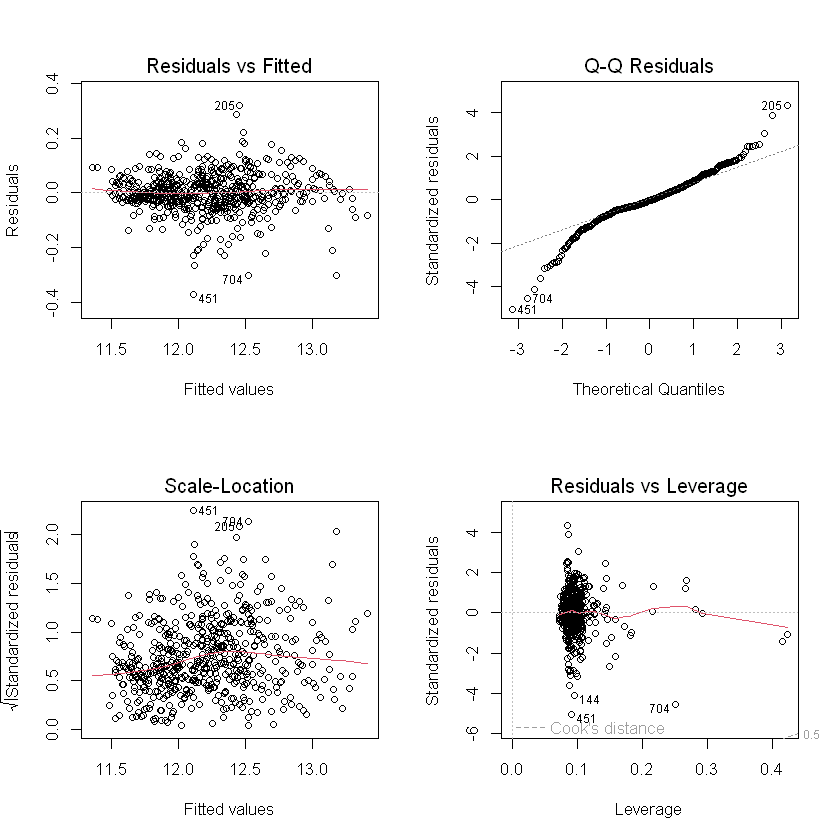

In [8]:
predictions <- predict(best_model, newdata = test_data)
rmse_value <- rmse(test_data$log_zhvi_real, predictions)
cat("RMSE:", rmse_value, "\n")

rss <- sum((predictions - test_data$log_zhvi_real)^2)
tss <- sum((test_data$log_zhvi_real - mean(test_data$log_zhvi_real))^2)
r_squared_value <- 1 - (rss / tss)
cat("R-squared:", r_squared_value, "\n")
par(mfrow = c(2, 2))
plot(best_model)
par(mfrow = c(1, 1)) 

As required by the assignment, I looked at outliers below and found that there are 41 outliers in the data. As each row represents a state-year, these 41 could represent economic or environmental effects that occured locally, such as a hurricane. I am hoping my FEMA inclusion accounts for that

Influential observations flagged (Cook's D > 4/n): 41 


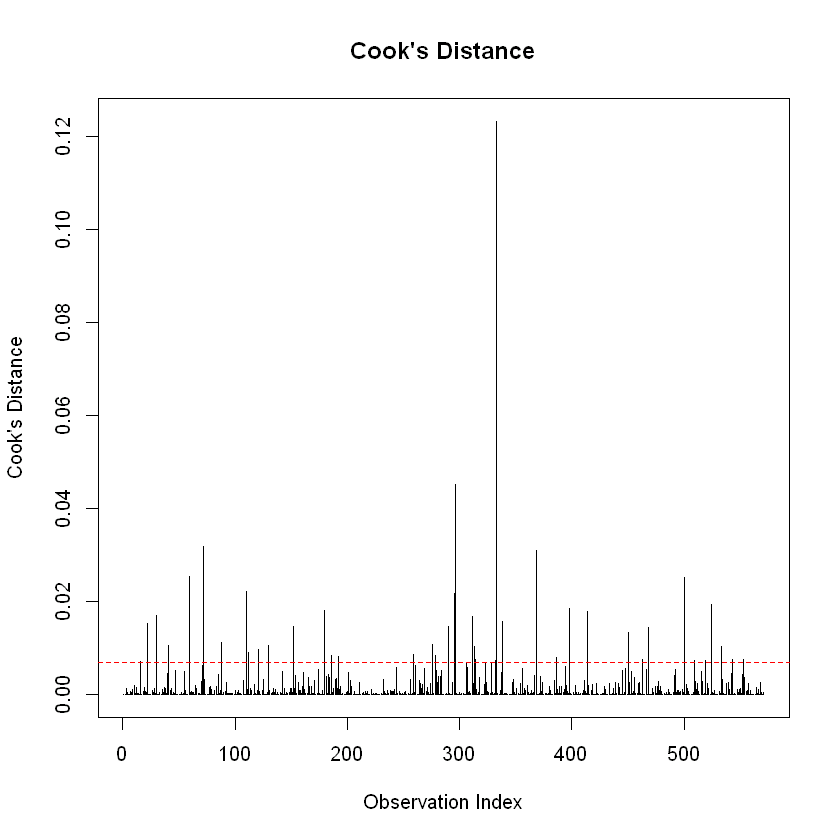

In [9]:
cooksd <- cooks.distance(best_model)
influential <- which(cooksd > 4 / nrow(train_data))
cat("Influential observations flagged (Cook's D > 4/n):", length(influential), "\n")

plot(cooksd, type = "h",
     main = "Cook's Distance",
     ylab = "Cook's Distance",
     xlab = "Observation Index")
abline(h = 4 / nrow(train_data), col = "red", lty = 2)

Now I want to train a mixed effects model to account for the state variable differently, but first I need to scale all numeric variables so that it does not affect model predictive performance. Once scaled, then a mixed model can be created and evaluated on out of sample test data similar to the "best" linear regression. Then the models can be compared. 

In [10]:
cols_to_scale <- c("year", "pop", "warn_events", "workers_affected", "closures", 
                   "layoffs", "disaster_declarations", "workers_affected_per_capita", 
                   "layoffs_per_capita", "layoffs_per_capita_lag1", 
                   "layoffs_per_capita_lag2", "disaster_declarations_lag1")

train_data_scaled <- train_data
test_data_scaled <- test_data
train_means <- colMeans(train_data[cols_to_scale])
train_sds   <- apply(train_data[cols_to_scale], 2, sd)
train_data_scaled[cols_to_scale] <- scale(train_data[cols_to_scale], center = train_means, scale = train_sds)
test_data_scaled[cols_to_scale] <- scale(test_data[cols_to_scale], center = train_means, scale = train_sds)

In [11]:
library(lme4)
mixed_model <- lmer(log_zhvi_real ~ year + pop + warn_events + workers_affected + 
                      closures + layoffs + disaster_declarations + 
                      workers_affected_per_capita + layoffs_per_capita +
                      layoffs_per_capita_lag1 + layoffs_per_capita_lag2 + 
                      disaster_declarations_lag1 + (1 | state), 
                    data = train_data_scaled)

summary(mixed_model)

mixed_predictions <- predict(mixed_model, newdata = test_data_scaled, allow.new.levels = TRUE)
mixed_rmse <- rmse(test_data_scaled$log_zhvi_real, mixed_predictions)
cat("RMSE:", mixed_rmse, "\n")

mixed_rss <- sum((mixed_predictions - test_data_scaled$log_zhvi_real)^2)
mixed_tss <- sum((test_data_scaled$log_zhvi_real - mean(test_data_scaled$log_zhvi_real))^2)
mixed_r_squared <- 1 - (mixed_rss / mixed_tss)
cat("R-squared:", mixed_r_squared, "\n")


Correlation matrix not shown by default, as p = 13 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML ['lmerMod']
Formula: log_zhvi_real ~ year + pop + warn_events + workers_affected +  
    closures + layoffs + disaster_declarations + workers_affected_per_capita +  
    layoffs_per_capita + layoffs_per_capita_lag1 + layoffs_per_capita_lag2 +  
    disaster_declarations_lag1 + (1 | state)
   Data: train_data_scaled

REML criterion at convergence: -901.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.5921 -0.4612 -0.0384  0.4800  4.1134 

Random effects:
 Groups   Name        Variance Std.Dev.
 state    (Intercept) 0.168835 0.41090 
 Residual             0.006213 0.07882 
Number of obs: 571, groups:  state, 51

Fixed effects:
                              Estimate Std. Error t value
(Intercept)                 12.2112705  0.0576335 211.878
year                         0.1319529  0.0035780  36.879
pop                          0.2326746  0.0482309   4.824
warn_events                 -0.0075489  0.0239724  -0.315
workers_affected            -

RMSE: 0.08487598 
R-squared: 0.9498889 


Thought the below might be a cool chart to include in the report, maybe one of the "showstoppers"

Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
"font family 'Times New Roman' not found in PostScript font database"

List of 136
 $ line                            :List of 6
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ lineend      : chr "butt"
  ..$ arrow        : logi FALSE
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_line" "element"
 $ rect                            :List of 5
  ..$ fill         : chr "white"
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_rect" "element"
 $ text                            :List of 11
  ..$ family       : chr ""
  ..$ face         : chr "plain"
  ..$ colour       : chr "black"
  ..$ size         : num 11
  ..$ hjust        : num 0.5
  ..$ vjust        : num 0.5
  ..$ angle        : num 0
  ..$ lineheight   : num 0.9
  ..$ margin       : 'margin' num [1:4] 0points 0points 0points 0points
  .. ..- attr(*, "unit")= int 8
  ..$ debug        : logi FALSE
  ..$ inherit.blank: l

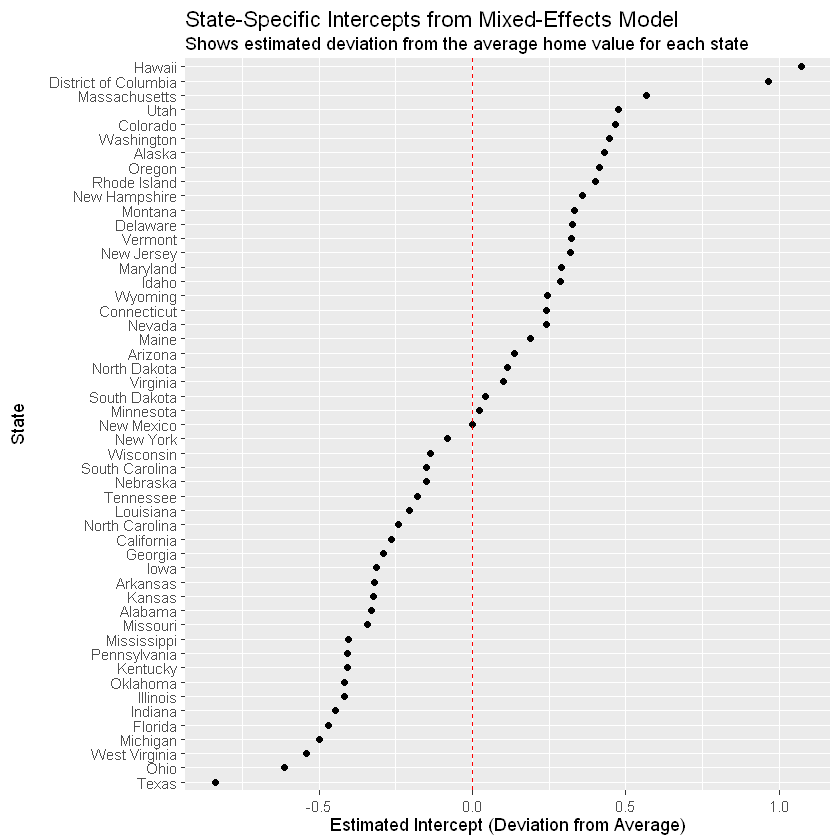

In [12]:
random_effects <- ranef(mixed_model, condVar = TRUE)

state_effects <- as.data.frame(random_effects$state)
state_effects$state <- rownames(state_effects)
colnames(state_effects)[1] <- "intercept_estimate"

ggplot(state_effects, aes(x = reorder(state, intercept_estimate), y = intercept_estimate)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  coord_flip()+
  labs(
    title = "State-Specific Intercepts from Mixed-Effects Model",
    subtitle = "Shows estimated deviation from the average home value for each state",
    x = "State",
    y = "Estimated Intercept (Deviation from Average)"
  )
  theme_minimal()